In [ ]:
!pip install transformers==4.41.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 696.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.2 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.1
    Uninstalling tokenizers-0.21.1:
      Successfully uninstalled tokenizers-0.21.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.50.2
    Uninstalling transformers-4.50.2:
      Successfully uninstalled transformers-4.50.2


In [ ]:
import transformers
print(transformers.__version__)

4.41.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score,recall_score , precision_score
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [ ]:
from transformers.optimization import AdamW

In [ ]:
# Load dataset
df = pd.read_csv("/content/phishing_site_urls.csv").dropna()

# Encode Labels
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
class_names = le.classes_

# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class PhishingDataset(Dataset):
    def __init__(self, urls, labels, tokenizer, max_length):
        self.urls = urls
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        url = self.urls[idx]
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            url,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:

# Split data
train_urls, test_urls, train_labels, test_labels = train_test_split(df['URL'], df['Label'], test_size=0.2, random_state=42)

# Create datasets
max_length = 64
train_dataset = PhishingDataset(train_urls.tolist(), train_labels.tolist(), tokenizer, max_length)
test_dataset = PhishingDataset(test_urls.tolist(), test_labels.tolist(), tokenizer, max_length)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512)

# Load pre-trained DistilBERT model (base model to get embeddings)
distilbert_model = DistilBertModel.from_pretrained('distilbert-base-uncased').to('cuda')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
# CNN Model
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_sizes, output_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim,
                      out_channels=n_filters,
                      kernel_size=fs)
            for fs in filter_sizes
        ])
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        # text = [batch size, seq len]
        embedded = self.dropout(self.embedding(text).permute(0, 2, 1))
        # embedded = [batch size, embedding dim, seq len]
        conved = [F.relu(conv(embedded)) for conv in self.convs]
        # conved[n] = [batch size, n filters, seq len - filter_sizes[n] + 1]
        pooled = [F.max_pool1d(conv, conv.shape[-1]).squeeze(-1) for conv in conved]
        # pooled[n] = [batch size, n filters]
        cat = self.dropout(torch.cat(pooled, dim=-1))
        # cat = [batch size, n filters * len(filter_sizes)]
        return self.fc(cat)

In [ ]:
# Initialize CNN model with the same parameters as before
cnn_embedding_dim = 128
cnn_n_filters = 100
cnn_filter_sizes = [3, 4, 5]
cnn_output_dim = 128
cnn_dropout = 0.5
cnn_model = CNNModel(tokenizer.vocab_size, cnn_embedding_dim, cnn_n_filters, cnn_filter_sizes, cnn_output_dim, cnn_dropout).to('cuda')

In [ ]:
# Initialize CNN model
cnn_embedding_dim = 128
cnn_n_filters = 100
cnn_filter_sizes = [3, 4, 5]
cnn_output_dim = 128 # Output dimension to match Transformer's output
cnn_dropout = 0.5
cnn_model = CNNModel(tokenizer.vocab_size, cnn_embedding_dim, cnn_n_filters, cnn_filter_sizes, cnn_output_dim, cnn_dropout).to('cuda')

In [ ]:
# Classification Layer
class CombinedModel(nn.Module):
    def __init__(self, distilbert_output_dim, cnn_output_dim, final_output_dim, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(distilbert_output_dim + cnn_output_dim, final_output_dim)

    def forward(self, distilbert_output, cnn_output):
        combined = torch.cat((distilbert_output, cnn_output), dim=-1)
        dropped = self.dropout(combined)
        return self.fc(dropped)


# nitialize Combined Model
distilbert_output_dim = distilbert_model.config.hidden_size
final_output_dim = 2 # Binary classification
combined_dropout = 0.3
combined_model = CombinedModel(distilbert_output_dim, cnn_output_dim, final_output_dim, combined_dropout).to('cuda')



In [ ]:
# Load the saved model state dictionary
save_path = "/content/combined_model.pth"
combined_model.load_state_dict(torch.load(save_path))
combined_model.eval() # Set the model to evaluation mode

CombinedModel(
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=896, out_features=2, bias=True)
)

In [ ]:
# Optimizer
optimizer = AdamW(list(distilbert_model.parameters()) + list(cnn_model.parameters()) + list(combined_model.parameters()), lr=5e-5)

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
# Training loop
def train_model(distilbert_model, cnn_model, combined_model, train_loader, optimizer, epochs):
    distilbert_model.train()
    cnn_model.train()
    combined_model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to('cuda')
            attention_mask = batch['attention_mask'].to('cuda')
            labels = batch['labels'].to('cuda')

            optimizer.zero_grad()

            # Get DistilBERT embeddings (using the base model)
            distilbert_outputs = distilbert_model(input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :] # Take the CLS token output

            # Get CNN output
            cnn_outputs = cnn_model(input_ids)

            # Combine outputs
            combined_outputs = combined_model(distilbert_outputs, cnn_outputs)

            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(combined_outputs, labels)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

# Train the model
epochs = 3
train_model(distilbert_model, cnn_model, combined_model, train_loader, optimizer, epochs)

Epoch 1 Loss: 0.6333
Epoch 1 Loss: 1.2110
Epoch 1 Loss: 1.8127
Epoch 1 Loss: 2.3406
Epoch 1 Loss: 2.8560
Epoch 1 Loss: 3.2972
Epoch 1 Loss: 3.7075
Epoch 1 Loss: 4.0987
Epoch 1 Loss: 4.5062
Epoch 1 Loss: 4.7901
Epoch 1 Loss: 5.1151
Epoch 1 Loss: 5.4184
Epoch 1 Loss: 5.6888
Epoch 1 Loss: 5.9707
Epoch 1 Loss: 6.1802
Epoch 1 Loss: 6.4794
Epoch 1 Loss: 6.7185
Epoch 1 Loss: 6.8938
Epoch 1 Loss: 7.0934
Epoch 1 Loss: 7.2720
Epoch 1 Loss: 7.4779
Epoch 1 Loss: 7.6492
Epoch 1 Loss: 7.8680
Epoch 1 Loss: 8.0543
Epoch 1 Loss: 8.2098
Epoch 1 Loss: 8.3716
Epoch 1 Loss: 8.5933
Epoch 1 Loss: 8.7551
Epoch 1 Loss: 8.9269
Epoch 1 Loss: 9.0751
Epoch 1 Loss: 9.2516
Epoch 1 Loss: 9.3927
Epoch 1 Loss: 9.5774
Epoch 1 Loss: 9.7173
Epoch 1 Loss: 9.8156
Epoch 1 Loss: 9.9315
Epoch 1 Loss: 10.0356
Epoch 1 Loss: 10.1938
Epoch 1 Loss: 10.3130
Epoch 1 Loss: 10.4492
Epoch 1 Loss: 10.5683
Epoch 1 Loss: 10.6996
Epoch 1 Loss: 10.8208
Epoch 1 Loss: 10.9442
Epoch 1 Loss: 11.1135
Epoch 1 Loss: 11.2481
Epoch 1 Loss: 11.3402
Ep

In [ ]:
save_path = "/content/combined_model.pth"
torch.save(combined_model, save_path)


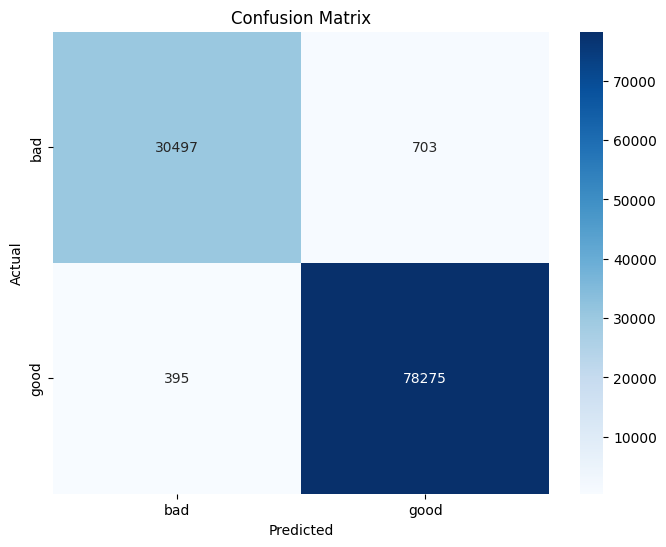


--- Overall Evaluation Metrics ---
Accuracy: 99.0006
Precision (Weighted): 0.9900
Recall (Weighted): 0.9900
F1-score (Weighted): 0.9900

----------------------------------

Classification Report (from sklearn):
              precision    recall  f1-score   support

         bad       0.99      0.98      0.98     31200
        good       0.99      0.99      0.99     78670

    accuracy                           0.99    109870
   macro avg       0.99      0.99      0.99    109870
weighted avg       0.99      0.99      0.99    109870



In [ ]:


def evaluate_model_with_visualization(distilbert_model, cnn_model, combined_model, test_loader, class_names):
    distilbert_model.eval()
    cnn_model.eval()
    combined_model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to('cuda')
            attention_mask = batch['attention_mask'].to('cuda')
            labels = batch['labels'].to('cuda')

            # Get DistilBERT embeddings
            distilbert_outputs = distilbert_model(input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

            # Get CNN output
            cnn_outputs = cnn_model(input_ids)

            # Combine outputs
            combined_outputs = combined_model(distilbert_outputs, cnn_outputs)

            _, predicted = torch.max(combined_outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    # Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)

    # Overall metrics using sklearn
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, average='weighted')  # 'weighted' averages over all labels
    recall = recall_score(all_labels, all_predictions, average='weighted')
    f1 = f1_score(all_labels, all_predictions, average='weighted')

    # Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Print overall metrics
    print("\n--- Overall Evaluation Metrics ---")
    print(f"Accuracy: {accuracy*100:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"Recall (Weighted): {recall:.4f}")
    print(f"F1-score (Weighted): {f1:.4f}")
    print("\n----------------------------------")

    # Print Classification Report
    print("\nClassification Report (from sklearn):")
    print(classification_report(all_labels, all_predictions, target_names=class_names))

# Evaluate the loaded model and visualize metrics
evaluate_model_with_visualization(distilbert_model, cnn_model, combined_model, test_loader, class_names)


In [ ]:
######################################################################### Individual model###############################################################################

In [ ]:
from functools import total_ordering
class CNNForClassification(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_sizes, hidden_dim, output_dim, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim,
                      out_channels=n_filters,
                      kernel_size=fs)
            for fs in filter_sizes
        ])
        self.fc1 = nn.Linear(len(filter_sizes) * n_filters, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text).permute(0, 2, 1))
        conved = [F.relu(conv(embedded)) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[-1]).squeeze(-1) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=-1))
        hidden = F.relu(self.fc1(cat))
        return self.fc2(hidden)

# Initialize this CNN model for individual training and evaluation
cnn_embedding_dim = 128
cnn_n_filters = 100
cnn_filter_sizes = [3, 4, 5]
cnn_hidden_dim = 64 # Added a hidden dimension
cnn_output_dim = 2
cnn_dropout = 0.5
cnn_pad_idx = tokenizer.pad_token_id
cnn_classification_model = CNNForClassification(tokenizer.vocab_size, cnn_embedding_dim, cnn_n_filters, cnn_filter_sizes, cnn_hidden_dim, cnn_output_dim, cnn_dropout, cnn_pad_idx).to('cuda')

# You would need to train this cnn_classification_model
criterion=nn.CrossEntropyLoss()
optimizer1=AdamW(cnn_classification_model.parameters(),lr=1e-4)

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:

def train(model, train_loader, optimizer1, criterion):
    model.train()
    for epoch in range(3):  # You can adjust the number of epochs
      total_loss = 0
      for batch in train_loader:
          input_ids = batch['input_ids'].to('cuda')
          labels = batch['labels'].to('cuda')
          optimizer1.zero_grad()
          outputs = model(input_ids)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer1.step()
          total_loss += loss.item()
          print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

train(cnn_classification_model, train_loader, optimizer1, criterion)

Epoch 1 Loss: 0.6101
Epoch 1 Loss: 1.2359
Epoch 1 Loss: 1.8678
Epoch 1 Loss: 2.4749
Epoch 1 Loss: 3.0882
Epoch 1 Loss: 3.6729
Epoch 1 Loss: 4.2783
Epoch 1 Loss: 4.8759
Epoch 1 Loss: 5.5054
Epoch 1 Loss: 6.1390
Epoch 1 Loss: 6.7498
Epoch 1 Loss: 7.3655
Epoch 1 Loss: 7.9666
Epoch 1 Loss: 8.5655
Epoch 1 Loss: 9.2065
Epoch 1 Loss: 9.8098
Epoch 1 Loss: 10.4200
Epoch 1 Loss: 11.0215
Epoch 1 Loss: 11.6427
Epoch 1 Loss: 12.2302
Epoch 1 Loss: 12.8541
Epoch 1 Loss: 13.4749
Epoch 1 Loss: 14.0954
Epoch 1 Loss: 14.6845
Epoch 1 Loss: 15.3192
Epoch 1 Loss: 15.9497
Epoch 1 Loss: 16.5300
Epoch 1 Loss: 17.1415
Epoch 1 Loss: 17.7459
Epoch 1 Loss: 18.3648
Epoch 1 Loss: 19.0098
Epoch 1 Loss: 19.5920
Epoch 1 Loss: 20.1926
Epoch 1 Loss: 20.8053
Epoch 1 Loss: 21.3946
Epoch 1 Loss: 21.9890
Epoch 1 Loss: 22.6094
Epoch 1 Loss: 23.2264
Epoch 1 Loss: 23.8055
Epoch 1 Loss: 24.3853
Epoch 1 Loss: 24.9705
Epoch 1 Loss: 25.5897
Epoch 1 Loss: 26.1899
Epoch 1 Loss: 26.7254
Epoch 1 Loss: 27.3352
Epoch 1 Loss: 27.9410
Epoc

Evaluation of CNN Model for Classification:
Accuracy: 92.8679
F1 Score: 0.9263
Precision: 0.9307
Recall: 0.9287
Confusion Matrix:
[[24431  6769]
 [ 1067 77603]]


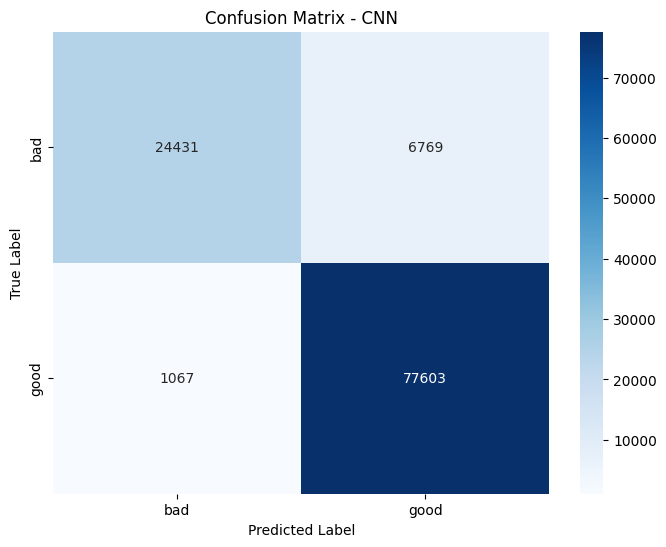

In [ ]:
def evaluate_cnn_model_explicit(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to('cuda')
            labels = batch['labels'].to('cuda')

            outputs = model(input_ids)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print("Evaluation of CNN Model for Classification:")
    print(f'Accuracy: {accuracy*100:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print('Confusion Matrix:')
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - CNN')
    plt.show()

evaluate_cnn_model_explicit(cnn_classification_model, test_loader)

In [ ]:
#################################################################### B.Tech part ##########################################################################

In [ ]:
!pip install transformers==4.41.0
import transformers
print(transformers.__version__)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score,recall_score , precision_score
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from transformers.optimization import AdamW

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
4.41.0


In [ ]:
import re
from urllib.parse import urlparse

def clean_url(url):
    url = str(url).strip().lower()
    url = re.sub(r'https?://', 'http ', url)
    url = re.sub(r'www\.', 'www ', url)
    return url


def safe_urlparse(url):
    try:
        return urlparse("http://" + url)
    except Exception:
        return None


def decompose_url(url):
    parsed = safe_urlparse(url)

    if parsed is None:
        return ""   #skip bad URLs safely

    domain = parsed.netloc.replace('.', ' . ')
    path = parsed.path.replace('/', ' / ')
    query = parsed.query.replace('&', ' & ').replace('=', ' = ')

    return f"{domain} {path} {query}"


def add_security_tokens(url):
    tokens = []

    keywords = ['login', 'verify', 'update', 'secure', 'account', 'bank', 'signin']
    tokens.extend([k for k in keywords if k in url])

    if re.search(r'\d{3,}', url):
        tokens.append('long_number')

    if url.count('-') > 2:
        tokens.append('many_hyphens')

    if len(url) > 75:
        tokens.append('long_url')

    if '@' in url:
        tokens.append('has_at_symbol')

    if url.count('.') > 3:
        tokens.append('many_subdomains')

    return " ".join(tokens)


def preprocess_url(url):
    try:
        raw = str(url).lower().strip()
        cleaned = clean_url(raw)
        decomposed = decompose_url(cleaned)
        features = add_security_tokens(raw)

        return f"{raw} {decomposed} {features}"

    except Exception:
        return raw  #fallback: return raw instead of crashing

# Load dataset
df1 = pd.read_csv("/content/phishing_site_urls.csv").dropna()
df2 = pd.read_csv("/content/PhiUSIIL_Phishing_URL_Dataset.csv").dropna()
df2 = df2.iloc[:,[1,-1]]
df2 = df2.rename(columns={'label': 'Label'})
df2['Label'] = df2['Label'].map({0: 'bad', 1: 'good'})
df = pd.concat([df1, df2])
df = df.sample(frac=1)
df['URL'] = df['URL'].apply(preprocess_url)
# Encode Labels
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
class_names = le.classes_

# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class PhishingDataset(Dataset):
    def __init__(self, urls, labels, tokenizer, max_length):
        self.urls = urls
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        url = self.urls[idx]
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            url,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
print("DF1 distribution:\n", df1['Label'].value_counts())
print("\nDF2 distribution:\n", df2['Label'].value_counts())

DF1 distribution:
 Label
good    392924
bad     156422
Name: count, dtype: int64

DF2 distribution:
 Label
good    134850
bad     100945
Name: count, dtype: int64


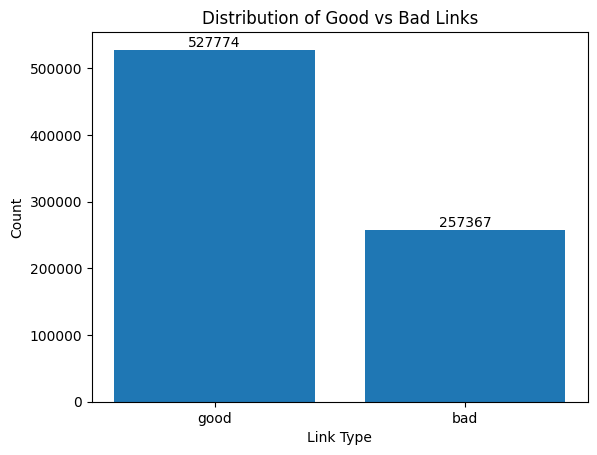

In [ ]:
import matplotlib.pyplot as plt

# Count labels
label_counts = df['Label'].value_counts()

# If encoded (0,1), map back to names
labels = [class_names[i] for i in label_counts.index]
counts = label_counts.values

# Plot
plt.figure()
plt.bar(labels, counts)

plt.xlabel("Link Type")
plt.ylabel("Count")
plt.title("Distribution of Good vs Bad Links")

# Show values on top
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [ ]:
# Split data
train_urls, test_urls, train_labels, test_labels = train_test_split(df['URL'], df['Label'], test_size=0.2, random_state=42)

# Create datasets
max_length = 64
train_dataset = PhishingDataset(train_urls.tolist(), train_labels.tolist(), tokenizer, max_length)
test_dataset = PhishingDataset(test_urls.tolist(), test_labels.tolist(), tokenizer, max_length)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512)

# Load pre-trained DistilBERT model (base model to get embeddings)
distilbert_model = DistilBertModel.from_pretrained('distilbert-base-uncased').to('cuda')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
# Load pre-trained DistilBERT model (base model to get embeddings)
distilbert_model = DistilBertModel.from_pretrained('distilbert-base-uncased').to('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
class LightweightMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Combined Model (unchanged structure)
class CombinedModel(nn.Module):
    def __init__(self, distilbert_output_dim, mlp_output_dim, final_output_dim, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(distilbert_output_dim + mlp_output_dim, final_output_dim)

    def forward(self, distilbert_output, mlp_output):
        combined = torch.cat((distilbert_output, mlp_output), dim=-1)
        combined = self.dropout(combined)
        return self.fc(combined)


# Initialize Combined Model
final_output_dim = 2
combined_dropout = 0.3

# Initialize MLP model
distilbert_output_dim = distilbert_model.config.hidden_size  # 768
mlp_hidden_dim = 256
mlp_output_dim = 128   # SAME as CNN output dim
mlp_dropout = 0.5

In [ ]:
mlp_model = LightweightMLP(distilbert_output_dim, mlp_hidden_dim, mlp_output_dim, mlp_dropout).to('cuda')

combined_model = CombinedModel(
    distilbert_output_dim,
    mlp_output_dim,
    final_output_dim,
    combined_dropout
).to('cuda')


# Optimizer (replace cnn_model with mlp_model)
optimizer = AdamW(
    list(distilbert_model.parameters()) +
    list(mlp_model.parameters()) +
    list(combined_model.parameters()),
    lr=5e-5
)

/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1 Loss: 0.0568
Epoch 2 Loss: 0.0228
Epoch 3 Loss: 0.0122


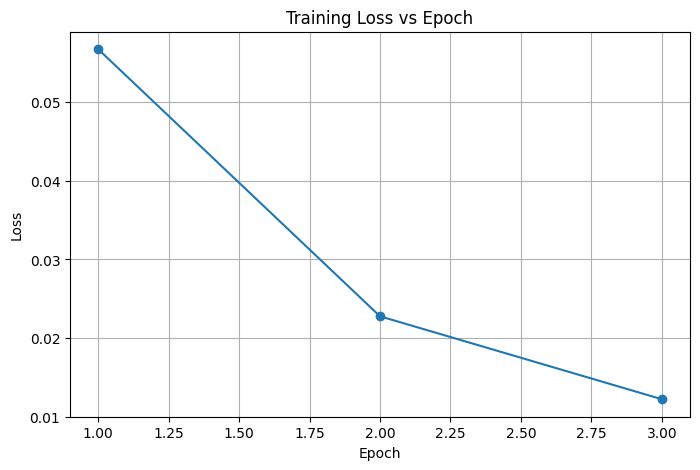

In [ ]:


# ================= TRAIN FUNCTION =================
def train_model(distilbert_model, mlp_model, combined_model, train_loader, optimizer, epochs):
    distilbert_model.train()
    mlp_model.train()
    combined_model.train()

    loss_fn = nn.CrossEntropyLoss()
    epoch_losses = []   # store loss per epoch

    for epoch in range(epochs):
        total_loss = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to('cuda')
            attention_mask = batch['attention_mask'].to('cuda')
            labels = batch['labels'].to('cuda')

            optimizer.zero_grad()

            # DistilBERT output
            distilbert_outputs = distilbert_model(
                input_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]  # CLS token

            # MLP output
            mlp_outputs = mlp_model(distilbert_outputs)

            # Combine
            outputs = combined_model(distilbert_outputs, mlp_outputs)

            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)  # ✅ better metric
        epoch_losses.append(avg_loss)

        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    return epoch_losses  # ✅ return list


# Train
epochs = 3
losses = train_model(distilbert_model, mlp_model, combined_model, train_loader, optimizer, epochs)

# ================= PLOT =================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.show()

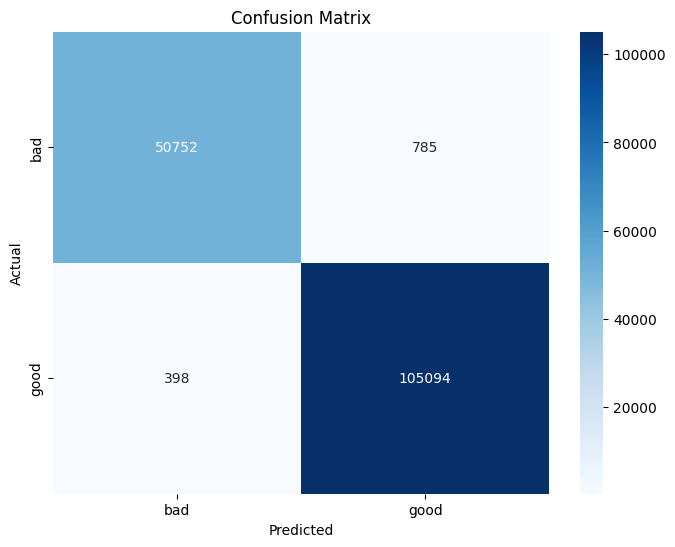


--- Overall Evaluation Metrics ---
Accuracy: 99.2466
Precision: 0.9925
Recall: 0.9925
F1-score: 0.9925

Classification Report:
              precision    recall  f1-score   support

         bad       0.99      0.98      0.99     51537
        good       0.99      1.00      0.99    105492

    accuracy                           0.99    157029
   macro avg       0.99      0.99      0.99    157029
weighted avg       0.99      0.99      0.99    157029



In [ ]:
# ================= EVALUATION =================
def evaluate_model_with_visualization(distilbert_model, mlp_model, combined_model, test_loader, class_names):
    distilbert_model.eval()
    mlp_model.eval()
    combined_model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to('cuda')
            attention_mask = batch['attention_mask'].to('cuda')
            labels = batch['labels'].to('cuda')

            distilbert_outputs = distilbert_model(
                input_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

            mlp_outputs = mlp_model(distilbert_outputs)

            outputs = combined_model(distilbert_outputs, mlp_outputs)

            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    cm = confusion_matrix(all_labels, all_predictions)

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, average='weighted')
    recall = recall_score(all_labels, all_predictions, average='weighted')
    f1 = f1_score(all_labels, all_predictions, average='weighted')

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("\n--- Overall Evaluation Metrics ---")
    print(f"Accuracy: {accuracy*100:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=class_names))


# Evaluate
evaluate_model_with_visualization(distilbert_model, mlp_model, combined_model, test_loader, class_names)

In [ ]:
save_path = "/content/phishing_model_complete.pth"

torch.save({
    'distilbert_state_dict': distilbert_model.state_dict(),
    'mlp_state_dict': mlp_model.state_dict(),
    'combined_state_dict': combined_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'label_classes': le.classes_,
    'class_names': class_names,
    'max_length': 128
}, save_path)

tokenizer.save_pretrained("/content/tokenizer/")

print("Model saved successfully!")

Model saved successfully!


In [1]:
!pip install transformers==4.41.0
import transformers
print(transformers.__version__)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizer, DistilBertModel
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import re
from urllib.parse import urlparse

def clean_url(url):
    url = str(url).strip().lower()
    url = re.sub(r'https?://', 'http ', url)
    url = re.sub(r'www\.', 'www ', url)
    return url


def safe_urlparse(url):
    try:
        return urlparse("http://" + url)
    except Exception:
        return None


def decompose_url(url):
    parsed = safe_urlparse(url)

    if parsed is None:
        return ""   #skip bad URLs safely

    domain = parsed.netloc.replace('.', ' . ')
    path = parsed.path.replace('/', ' / ')
    query = parsed.query.replace('&', ' & ').replace('=', ' = ')

    return f"{domain} {path} {query}"


def add_security_tokens(url):
    tokens = []

    keywords = ['login', 'verify', 'update', 'secure', 'account', 'bank', 'signin']
    tokens.extend([k for k in keywords if k in url])

    if re.search(r'\d{3,}', url):
        tokens.append('long_number')

    if url.count('-') > 2:
        tokens.append('many_hyphens')

    if len(url) > 75:
        tokens.append('long_url')

    if '@' in url:
        tokens.append('has_at_symbol')

    if url.count('.') > 3:
        tokens.append('many_subdomains')

    return " ".join(tokens)


def preprocess_url(url):
    try:
        raw = str(url).lower().strip()
        cleaned = clean_url(raw)
        decomposed = decompose_url(cleaned)
        features = add_security_tokens(raw)

        return f"{raw} {decomposed} {features}"

    except Exception:
        return raw

checkpoint = torch.load(
    "/content/phishing_model_complete.pth",
    map_location=device,
    weights_only=False   # <-- IMPORTANT (fixes your error)
)

# Recreate your models EXACTLY like training
distilbert_model1 = DistilBertModel.from_pretrained('distilbert-base-uncased')
distilbert_output_dim = distilbert_model1.config.hidden_size  # 768
mlp_hidden_dim = 256
mlp_output_dim = 128   # SAME as CNN output dim
mlp_dropout = 0.5

class LightweightMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Combined Model (unchanged structure)
class CombinedModel(nn.Module):
    def __init__(self, distilbert_output_dim, mlp_output_dim, final_output_dim, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(distilbert_output_dim + mlp_output_dim, final_output_dim)

    def forward(self, distilbert_output, mlp_output):
        combined = torch.cat((distilbert_output, mlp_output), dim=-1)
        combined = self.dropout(combined)
        return self.fc(combined)


# Initialize Combined Model
final_output_dim = 2
combined_dropout = 0.3

# Initialize MLP model
distilbert_output_dim = distilbert_model1.config.hidden_size  # 768
mlp_hidden_dim = 256
mlp_output_dim = 128   # SAME as CNN output dim
mlp_dropout = 0.5

# Initialize Combined Model
final_output_dim = 2
combined_dropout = 0.3
mlp_model1 = LightweightMLP(distilbert_output_dim, mlp_hidden_dim, mlp_output_dim, mlp_dropout)            # same params
combined_model1 = CombinedModel(
    distilbert_output_dim,
    mlp_output_dim,
    final_output_dim,
    combined_dropout
)  # same params

distilbert_model1.to(device)
mlp_model1.to(device)
combined_model1.to(device)

distilbert_model1.load_state_dict(checkpoint['distilbert_state_dict'])
mlp_model1.load_state_dict(checkpoint['mlp_state_dict'])
combined_model1.load_state_dict(checkpoint['combined_state_dict'])


tokenizer = DistilBertTokenizer.from_pretrained("/content/tokenizer/")

distilbert_model1.eval()
mlp_model1.eval()
combined_model1.eval()

def predict_url(url):
    # same preprocessing
    processed_url = preprocess_url(url)

    encoding = tokenizer.encode_plus(
        processed_url,
        add_special_tokens=True,
        max_length=64,   #  use SAME as training (you used 64)
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        # DistilBERT
        distilbert_output = distilbert_model1(
            input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]

        # MLP
        mlp_output = mlp_model1(distilbert_output)

        # Combined
        outputs = combined_model1(distilbert_output, mlp_output)

        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy()

url = "www.japan.com"

pred, probs = predict_url(url)

label_map = checkpoint['class_names']   # ['bad', 'good']

print("URL:", url)
print("Prediction:", label_map[pred])
print("Confidence:", probs)

if label_map[pred] == "bad":
    print("⚠️ Phishing URL detected!")
else:
    print("✅ Safe URL")

'''from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.classes_ = checkpoint['label_classes']

class_names = checkpoint['class_names']
max_length = checkpoint['max_length']'''



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 102.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
4.41.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

URL: www.japan.com
Prediction: bad
Confidence: [[0.59631    0.40368995]]
⚠️ Phishing URL detected!


"from sklearn.preprocessing import LabelEncoder\n\nle = LabelEncoder()\nle.classes_ = checkpoint['label_classes']\n\nclass_names = checkpoint['class_names']\nmax_length = checkpoint['max_length']"

In [4]:
url = "www.google.com"

pred, probs = predict_url(url)

label_map = checkpoint['class_names']   # ['bad', 'good']

print("URL:", url)
print("Prediction:", label_map[pred])
print("Confidence:", probs)

if label_map[pred] == "bad":
    print("Phishing URL detected!")
else:
    print("Safe URL")

URL: www.google.com
Prediction: good
Confidence: [[0.33619353 0.66380644]]
Safe URL


In [5]:
def check_url(url):
    pred, probs = predict_url(url)

    label_map = checkpoint['class_names']  # ['bad', 'good']

    prediction = label_map[pred]
    confidence = probs

    if prediction == "bad":
        result = "Phishing URL detected!"
    else:
        result = "Safe URL"

    return f"{result}"


import gradio as gr

iface = gr.Interface(
    fn=check_url,
    inputs=gr.Textbox(label="Enter URL", placeholder="e.g. www.example.com"),
    outputs=gr.Textbox(label="Result"),
    title="Phishing URL Detector",
    description="Enter a URL to check whether it is safe or phishing."
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bbbab27019d4c32e96.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
class URLCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_classes=2):
        super(URLCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=3, padding=1)

        self.pool = nn.AdaptiveMaxPool1d(1)

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids):
        x = self.embedding(input_ids)          # (B, L, E)
        x = x.permute(0, 2, 1)                 # (B, E, L)

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = self.pool(x).squeeze(-1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = URLCNN(vocab_size=tokenizer.vocab_size).to(device)

optimizer = torch.optim.Adam(model1.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
from tqdm import tqdm

def train_model(model1, loader):
    model1.train()
    total_loss = 0

    for batch in tqdm(loader):
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model1(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_model(model1, loader):
    model1.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model1(input_ids)
            predictions = torch.argmax(outputs, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    print("Classification Report:\n", classification_report(true, preds))
    print("Confusion Matrix:\n", confusion_matrix(true, preds))

In [ ]:
epochs = 3

for epoch in range(epochs):
    loss = train_model(model1, train_loader)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

evaluate_model(model1, test_loader)

100%|██████████| 1227/1227 [05:59<00:00,  3.41it/s]


Epoch 1, Loss: 0.0963


100%|██████████| 1227/1227 [06:00<00:00,  3.40it/s]


Epoch 2, Loss: 0.0461


100%|██████████| 1227/1227 [05:57<00:00,  3.43it/s]


Epoch 3, Loss: 0.0318
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98     51537
           1       0.99      0.99      0.99    105492

    accuracy                           0.99    157029
   macro avg       0.99      0.98      0.99    157029
weighted avg       0.99      0.99      0.99    157029

Confusion Matrix:
 [[ 50207   1330]
 [   704 104788]]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['URL'])
y = df['Label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=20)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.92      0.82      0.87     51586
           1       0.92      0.96      0.94    105443

    accuracy                           0.92    157029
   macro avg       0.92      0.89      0.90    157029
weighted avg       0.92      0.92      0.92    157029

[[ 42240   9346]
 [  3767 101676]]
Random Forest
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     51586
           1       0.96      0.98      0.97    105443

    accuracy                           0.96    157029
   macro avg       0.96      0.95      0.96    157029
weighted avg       0.96      0.96      0.96    157029

[[ 47302   4284]
 [  1742 103701]]
Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     51586
           1       0.95      0.98      0.96    105443

    accuracy                           0.95    157029
   macro a

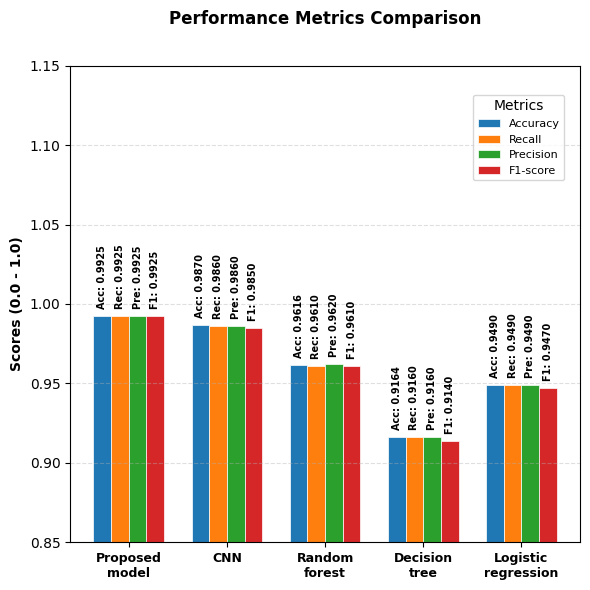

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Preparation ---
models = ["Proposed\nmodel", "CNN", "Random\nforest", "Decision\ntree", "Logistic\nregression"]

metrics = {
    'Accuracy':  [0.99246, 0.9870, 0.9616, 0.9164, 0.9490],
    'Recall':    [0.9925,  0.9860, 0.9610, 0.9160, 0.9490],
    'Precision': [0.9925,  0.9860, 0.9620, 0.9160, 0.9490],
    'F1-score':  [0.9925,  0.9850, 0.9610, 0.9140, 0.9470]
}

x = np.arange(len(models))
width = 0.18
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- 2. Setup Plot ---
fig, ax = plt.subplots(figsize=(6, 6))

multiplier = 0
for i, (metric_name, measurement) in enumerate(metrics.items()):
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=metric_name,
                  color=colors[i], edgecolor='white', linewidth=0.5)

    prefix = "F1" if metric_name == 'F1-score' else metric_name[:3]
    labels = [f"{prefix}: {val:.4f}" for val in measurement]

    # Vertical labels
    ax.bar_label(rects, labels=labels, padding=5, fontsize=7,
                 fontweight='bold', rotation=90, label_type='edge')

    multiplier += 1

# --- 3. Positioning and Legend ---

# Y-axis focus
ax.set_ylim(0.85, 1.15)
ax.set_ylabel('Scores (0.0 - 1.0)', fontsize=10, fontweight='bold')

# X-axis labels
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(models, fontsize=9, fontweight='bold')

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# --- KEY FIX: Padded Legend Position ---
# bbox_to_anchor=(x, y) coordinates:
# x=0.98 provides padding from the right edge.
# y=0.95 moves it slightly down from the top edge.
ax.legend(loc='upper right', bbox_to_anchor=(0.98, 0.95),
          frameon=True, fontsize=8, title="Metrics")

# Title
ax.set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()